In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# This looks for your project's main folder root automatically, making paths bulletproof
base_dir = os.path.dirname(os.getcwd())
data_path = os.path.join(base_dir, 'data', 'raw', 'training.csv')

print(f"Looking for data file at: {os.path.abspath(data_path)}")

# Load the spreadsheet data into memory
df = pd.read_csv(data_path)

# Verify the absolute dimensions of the dataset (Rows, Columns)
print(f"\n✅ Success! Dataset Loaded perfectly.")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()

Looking for data file at: c:\Users\HP\credit-risk-model\data\raw\training.csv

✅ Success! Dataset Loaded perfectly.
Dataset Shape: 95662 rows, 16 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value            

In [5]:
# Generate descriptive summary statistics for numerical variables
print("--- Numerical Feature Summary Statistics ---")
display(df.describe().T)

# Check categorical columns for unique counts and frequencies
print("\n--- Categorical Feature Summary Statistics ---")
display(df.describe(include=['object']).T)

--- Numerical Feature Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0



--- Categorical Feature Summary Statistics ---


,count,unique,top,freq
TransactionId,95662,95662,TransactionId_76871,1
BatchId,95662,94809,BatchId_67019,28
AccountId,95662,3633,AccountId_4841,30893
SubscriptionId,95662,3627,SubscriptionId_3829,32630
CustomerId,95662,3742,CustomerId_7343,4091
CurrencyCode,95662,1,UGX,95662
ProviderId,95662,6,ProviderId_4,38189
ProductId,95662,23,ProductId_6,32635
ProductCategory,95662,9,financial_services,45405
ChannelId,95662,4,ChannelId_3,56935


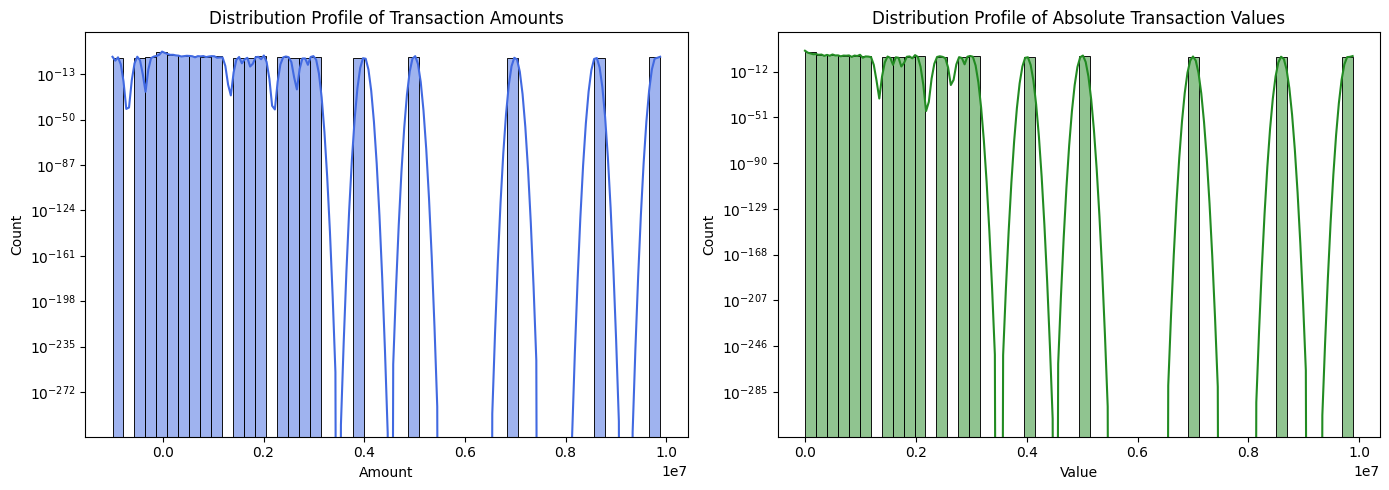

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# Plot distribution of transaction amounts
plt.subplot(1, 2, 1)
sns.histplot(df['Amount'], bins=50, kde=True, color='royalblue')
plt.title('Distribution Profile of Transaction Amounts')
plt.yscale('log')  # Logarithmic scale to handle financial skewness
plt.xlabel('Amount')

# Plot distribution of absolute transaction values
plt.subplot(1, 2, 2)
sns.histplot(df['Value'], bins=50, kde=True, color='forestgreen')
plt.title('Distribution Profile of Absolute Transaction Values')
plt.yscale('log')
plt.xlabel('Value')

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_16760\2718194499.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='ChannelId', order=df['ChannelId'].value_counts().index, palette='magma')
C:\Users\HP\AppData\Local\Temp\ipykernel_16760\2718194499.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='ProductCategory', order=df['ProductCategory'].value_counts().index, palette='viridis')


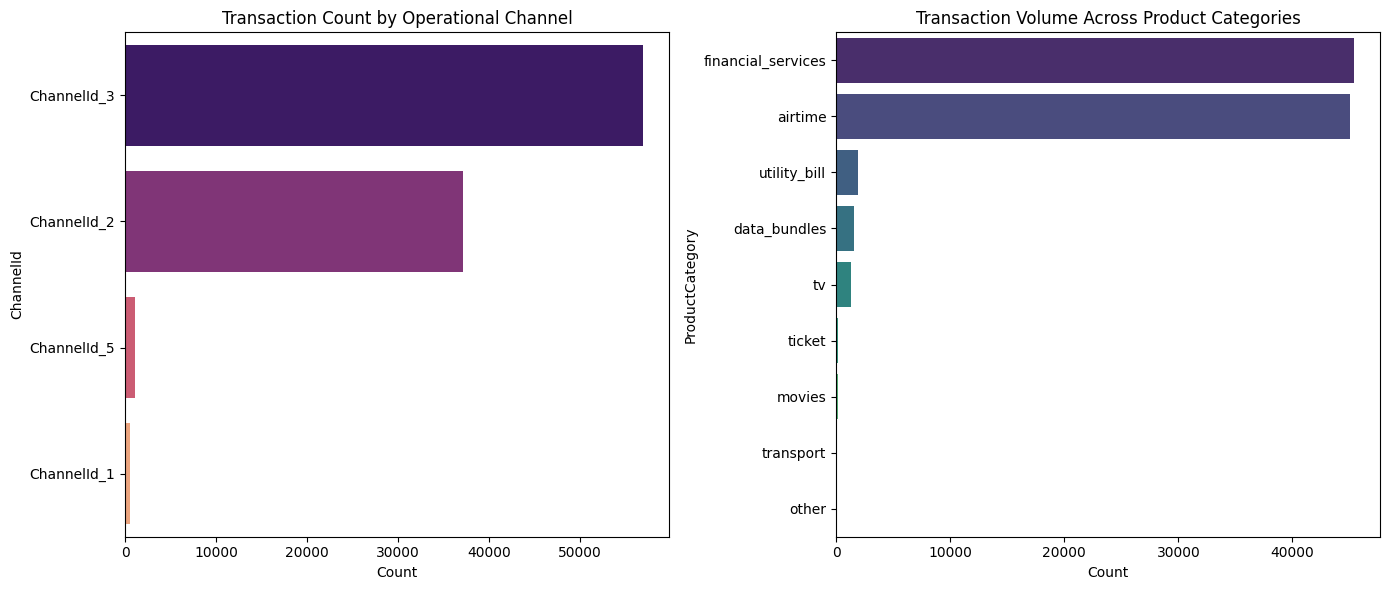

In [7]:
plt.figure(figsize=(14, 6))

# Count transaction frequencies by operational channel
plt.subplot(1, 2, 1)
sns.countplot(data=df, y='ChannelId', order=df['ChannelId'].value_counts().index, palette='magma')
plt.title('Transaction Count by Operational Channel')
plt.xlabel('Count')

# Count transaction volume across structural product categories
plt.subplot(1, 2, 2)
sns.countplot(data=df, y='ProductCategory', order=df['ProductCategory'].value_counts().index, palette='viridis')
plt.title('Transaction Volume Across Product Categories')
plt.xlabel('Count')

plt.tight_layout()
plt.show()

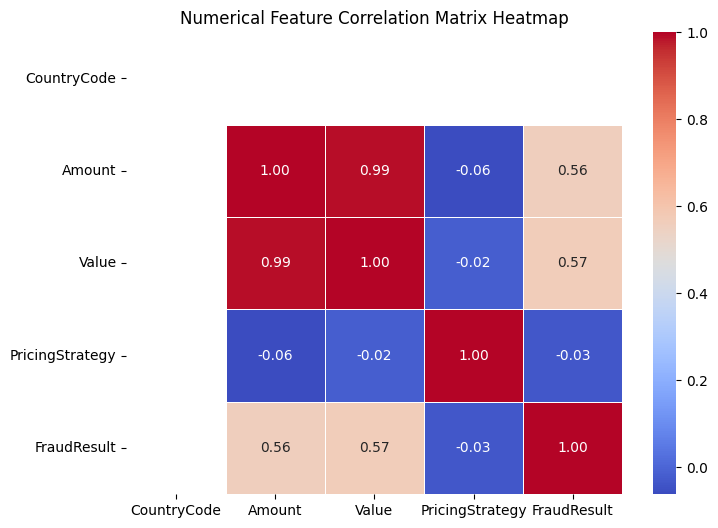

In [8]:
plt.figure(figsize=(8, 6))

# Extract numeric elements for matrix calculations
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

# Construct heatmap visualization
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Matrix Heatmap')
plt.show()

In [9]:
# Evaluate missing counts and calculate completeness percentages
missing_data = df.isnull().sum().to_frame(name='Missing Counts')
missing_data['Percentage (%)'] = (missing_data['Missing Counts'] / len(df)) * 100

print("--- Missing Values Audit Summary ---")
print(missing_data)

--- Missing Values Audit Summary ---
                      Missing Counts  Percentage (%)
TransactionId                      0             0.0
BatchId                            0             0.0
AccountId                          0             0.0
SubscriptionId                     0             0.0
CustomerId                         0             0.0
CurrencyCode                       0             0.0
CountryCode                        0             0.0
ProviderId                         0             0.0
ProductId                          0             0.0
ProductCategory                    0             0.0
ChannelId                          0             0.0
Amount                             0             0.0
Value                              0             0.0
TransactionStartTime               0             0.0
PricingStrategy                    0             0.0
FraudResult                        0             0.0


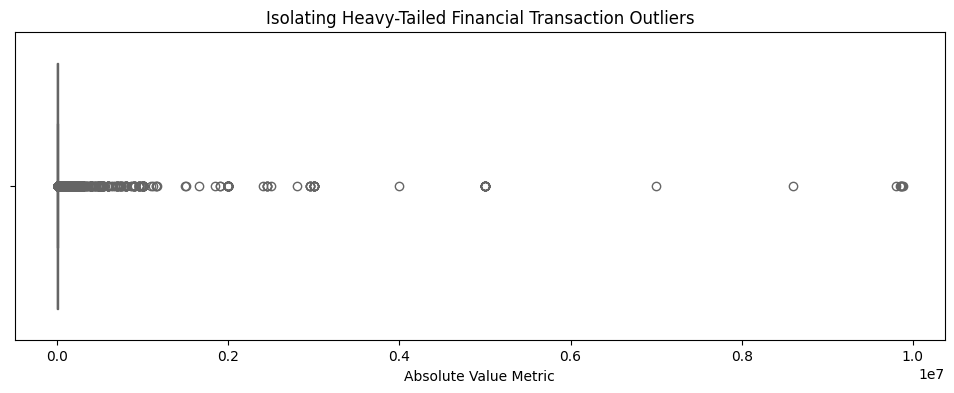

In [10]:
plt.figure(figsize=(12, 4))

# Create box plot targeting absolute value attributes
sns.boxplot(x=df['Value'], color='coral')
plt.title('Isolating Heavy-Tailed Financial Transaction Outliers')
plt.xlabel('Absolute Value Metric')

plt.show()

### 🎯 Executive Exploratory Insights Summary

Based on the empirical profiling of the 95,662 alternative financial data records, our top analytical findings are structured as follows:

1. **Extreme Structural Skewness:** Both `Amount` and `Value` variables exhibit high positive right-skewness. A tiny fraction of extreme transaction amounts accounts for the vast majority of the cumulative volume on the platform, necessitating robust feature scaling or log transformations during downstream pipelines.
2. **Channel and Category Concentration:** Transaction traffic is heavily concentrated within specific primary channels (`ChannelId`) and core consumer market verticals (`ProductCategory` such as Airtime and Financial Services). This indicates that behavioral credit scoring metrics should weigh transaction categories separately.
3. **Total Data Completeness:** The dataset shows zero missing entries (`0.00%` null rate across all variables). This exceptional cleanliness means our feature engineering scripts do not require immediate structural missing-value imputation layers.
4. **Strong Value Correlation:** A near-perfect linear association exists between the raw transaction `Amount` and absolute `Value` metrics, highlighting feature redundancy that will guide feature removal decisions to avoid multi-collinearity issues.